<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pytorch Computer Vision
* `torch.vision` : https://www.learnpytorch.io/03_pytorch_computer_vision/
* `tourchvision.datasets` get datasets and data loading function  for computer from here
* `torchvision.models` - get oretrained computer vision models that you leverage for your own problems
* `tochvision.transforms` functions for manipulatinf the vision data to be suitable for use with ML model
* `torch.utils.data.Dataset` Base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Creates a python iterable over a dataset

In [86]:
import torch
from torch import nn

import pandas as pd
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


import matplotlib.pyplot as plt


In [87]:
##Training Data
train_data = datasets.FashionMNIST(
  root = "data", #Where to download the data to ?
  train = True, #get training data
  download = True, #download data if it doesn't exist
  transform=ToTensor(), #convert to tensor
  target_transform=None
)

In [88]:
#Testing Data
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform=None
)


In [89]:
len(train_data), len(test_data)

(60000, 10000)

In [90]:
##See the first training example
image , label = train_data[0]
image , label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [91]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [92]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [93]:
image.shape ,  label

(torch.Size([1, 28, 28]), 9)

Image Shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

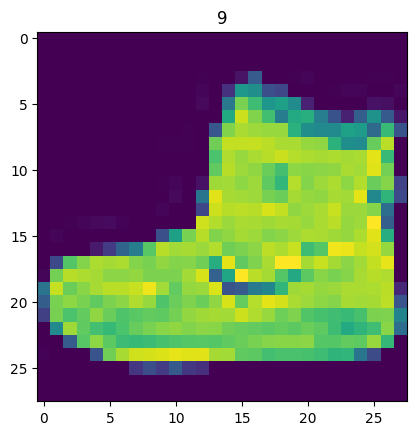

In [94]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

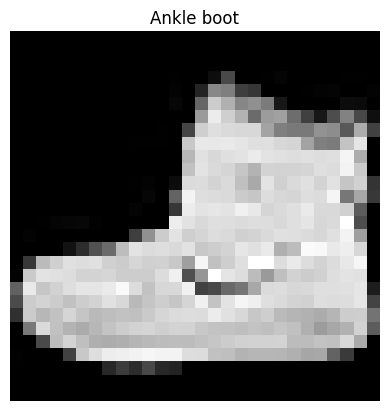

In [95]:
plt.imshow(image.squeeze(),cmap ="gray")
plt.title(class_names[label]);
plt.axis(False);

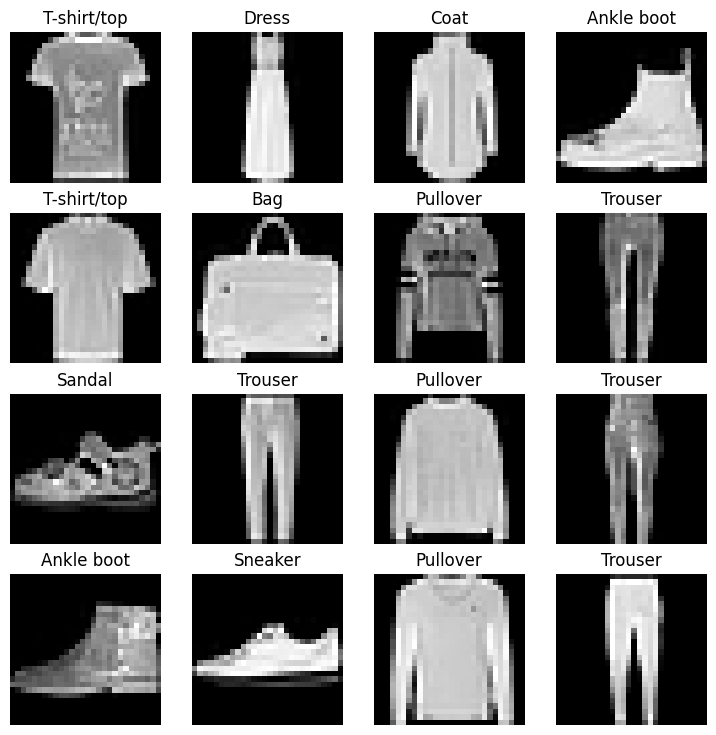

In [96]:
# torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows, cols = 4,4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item() # Add parentheses here
  img , label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [97]:
##Preparing Dara Loader
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

#Data Loader turns the dataset into a pythorn

#breaking them unto batches :

* It is more computationally efficient
* It may not be able to look stroe in memory

In [98]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)
test_dataloader = DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)


In [99]:
print(f"Data Loaders : {train_dataloader, test_dataloader} ")
print(f"Length of the dataloader : {len(train_dataloader)}batches of batch size {BATCH_SIZE}")
print(f"Length of the dataloader : {len(test_dataloader)}batches of batch size {BATCH_SIZE}")

Data Loaders : (<torch.utils.data.dataloader.DataLoader object at 0x7d70f351f5f0>, <torch.utils.data.dataloader.DataLoader object at 0x7d70f9b0e6c0>) 
Length of the dataloader : 1875batches of batch size 32
Length of the dataloader : 313batches of batch size 32


In [100]:
#show a sample
train_features_batch , train_labels_batch = next(iter(train_dataloader))

In [101]:
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size :torch.Size([1, 28, 28])
Label : 2, label size = torch.Size([])


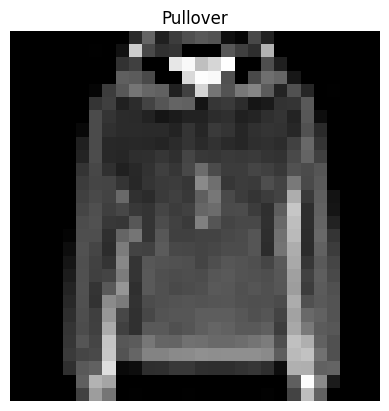

In [102]:
random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()
img ,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "grey")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size :{img.shape}")
print(f"Label : {label}, label size = {label.shape}")


##Building a baseline model for torch vision

* When starting t build ml model, it is best practice to start with baseline model
* A baseline model is a simple model we will tryn and improve upon with subsequent model/experiment


In [103]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x) # perform forward pass

# printing out whatr happened

print(f"Shape before flattening {x.shape}")
print(f"Shape after flattening {output.shape}")


Shape before flattening torch.Size([1, 28, 28])
Shape after flattening torch.Size([1, 784])


In [104]:
# to reduce the dinmensionality of lots of features bsaically a flatten is used

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape:int,hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,
                  out_features = hidden_units),
        nn.Linear(in_features = hidden_units,
                  out_features = output_shape)
        )
  def forward(self, x)->torch.tensor:
          return self.layer_stack(x)

In [105]:
#creating a n instance of the model
model_0 = FashionMNISTModelV0(
    input_shape = 784,
    hidden_units= 10,
    output_shape = len(class_names)
).to("cpu")

In [106]:
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [107]:
dummy_x = torch.rand([1,1,28,28])

In [108]:
model_0(dummy_x)

tensor([[ 0.1334, -0.4430, -0.2932,  0.0629, -0.0499, -0.5541, -0.2834,  0.0949,
         -0.3574,  0.3064]], grad_fn=<AddmmBackward0>)

In [109]:
model_0.state_dict()


OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0285, -0.0219, -0.0141,  ...,  0.0007,  0.0141,  0.0041],
                      [ 0.0007, -0.0278, -0.0111,  ...,  0.0147,  0.0166,  0.0298],
                      [ 0.0130, -0.0073,  0.0315,  ..., -0.0196,  0.0344, -0.0101],
                      ...,
                      [ 0.0079,  0.0153,  0.0312,  ...,  0.0193, -0.0216,  0.0091],
                      [ 0.0009,  0.0136, -0.0101,  ...,  0.0198, -0.0071, -0.0208],
                      [ 0.0006, -0.0266,  0.0207,  ..., -0.0157,  0.0279, -0.0327]])),
             ('layer_stack.1.bias',
              tensor([-0.0079,  0.0326, -0.0035,  0.0191,  0.0210,  0.0341, -0.0253,  0.0192,
                      -0.0167,  0.0011])),
             ('layer_stack.2.weight',
              tensor([[-0.0619, -0.1010, -0.3005,  0.0796,  0.1844, -0.1770, -0.0548,  0.1896,
                       -0.2628,  0.1273],
                      [-0.2177,  0.3138, -0.3091, -0.1005, -0.0061,  0.2877, -0.

#what wil our loss Function be ?
* since we have used all the multi class data our loss function will be `nn.CrossEntropyLoss()`
* Optimizer we are ging to be using is torch.optim.sgd
* we can use a torchmetrics to ise the libbrary and we could copy the finction straight in to our notebook  and  Calculate accuracy


In [110]:
##Iporting helperfuunctions.py

import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functoins already exist")
else:
  requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb")as f: ##this sets the permissipon of the file to write binary functions here in the file
    f.write(requests.content)  #now we write the contents inside the helper function.py file we just created





helper_functoins already exist


In [113]:
from helper_functions import accuracy_fn





In [114]:
#setting up loss function and optimizer
Loss_fn = torch.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)
#creating a function to time pour experiment


TypeError: accuracy_fn() missing 2 required positional arguments: 'y_true' and 'y_pred'

#creating a function to time our experiments

* Machine learning is very experimental, twi of the main thing you would want to track is the model performance etc and the second part is how fast it runs



In [123]:
from timeit import default_timer as timer
def train_time(start:float,
               end:float,
               device: torch.device = None):
  total_time = end-start
  print(f"Total Time on {device} : {total_time:.3f} seconds")
  return total_time

In [124]:
#sample on how to use the timeit funciton

start_time = timer()
"""
Some code
"""
end_time = timer()
print(f"total time : {train_time(start_time, end_time)}")

Total Time on None : 0.000 seconds
total time : 3.544199989846675e-05
